# 📊 **APE 011 – Distribuciones Muestrales y Teorema del Límite Central**
## Simulación Estocástica aplicada al Dataset Regional de Loja

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

**Objetivo:** Evalúa el comportamiento probabilístico
de variables aleatorias continuas
mediante el ajuste a la distribución
Normal y el cálculo de áreas bajo la curva,
aplicando estandarización (puntajes Z)
para la toma de decisiones basada en
datos empíricos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


---
## 📐Tarea 1: Análisis de Varianza (ANOVA de 1 factor)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos
np.random.seed(42)
grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)
stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)
print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")

Estadístico F: 22.6087 | Valor-p: 1.2389e-08


---
## 🔁Tarea 2: Hito del Proyecto - Segmentación Multigrupo

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales (1).xlsx


In [ ]:
import pandas as pd
from scipy.stats import f_oneway

df = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

variable_categorica = "Régimen laboral al que pertenece\xa0"
variable_numerica = "Remuneración mensual unificada"

# Eliminar valores nulos
datos = df[[variable_categorica, variable_numerica]].dropna()

print("****************************************")
print("Niveles de la variable categórica")
print("****************************************")

niveles = datos[variable_categorica].unique()

for nivel in niveles:
    cantidad = len(datos[datos[variable_categorica] == nivel])
    print(f"{nivel} -> {cantidad} registros")

grupos = []

for nivel in niveles:
    grupo = datos.loc[
        datos[variable_categorica] == nivel,
        variable_numerica
    ]
    grupos.append(grupo)

F, p = f_oneway(*grupos)

print("\n**************************************")
print("RESULTADOS DEL ANOVA")
print("****************************************")

print(f"Estadístico F = {F:.4f}")
print(f"Valor p       = {p:.6f}")

alpha = 0.05


****************************************
Niveles de la variable categórica
****************************************
LOSEP -> 1425 registros
CODIGO DE TRABAJO -> 1308 registros
LOSEP-SOC -> 139 registros
LOSEP-CONCEJAL -> 11 registros

**************************************
RESULTADOS DEL ANOVA
****************************************
Estadístico F = 442.2650
Valor p       = 0.000000


# 📝 DICTAMEN TÉCNICO

📌 **Con un nivel de significancia de 0.05,**  
el valor **p (0.000000)** es menor que **α**.

❌ **Se rechaza la hipótesis nula.**

📈 **El análisis ANOVA sugiere que existen diferencias**
estadísticamente significativas entre las medias de la
**'Remuneración mensual unificada'** para los distintos
**regímenes laborales**.

✅ **No todas las medias son iguales.**

🔎 **Debido a que el ANOVA únicamente indica que existe al menos**
una diferencia significativa, se recomienda realizar una
**prueba post hoc** (por ejemplo, **Tukey HSD**) para identificar
qué grupos presentan dichas diferencias.

---
📚 **Conclusión:** Se recomienda complementar el análisis con una prueba **Tukey HSD** para determinar específicamente entre qué regímenes laborales existen diferencias significativas.

---
## 🌎Tarea 3: Pruebas Post-hoc (Tukey HSD)


RESULTADOS DE LA PRUEBA POST HOC DE TUKEY
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1          group2      meandiff p-adj   lower     upper   reject
---------------------------------------------------------------------------
CODIGO DE TRABAJO          LOSEP  252.5691   0.0  230.9689  274.1694   True
CODIGO DE TRABAJO LOSEP-CONCEJAL 1495.8505   0.0 1325.0565 1666.6444   True
CODIGO DE TRABAJO      LOSEP-SOC  138.1774   0.0   87.8536  188.5012   True
            LOSEP LOSEP-CONCEJAL 1243.2813   0.0 1072.5458 1414.0168   True
            LOSEP      LOSEP-SOC -114.3917   0.0 -164.5166  -64.2667   True
   LOSEP-CONCEJAL      LOSEP-SOC -1357.673   0.0 -1534.355 -1180.991   True
---------------------------------------------------------------------------


<Figure size 1200x720 with 0 Axes>

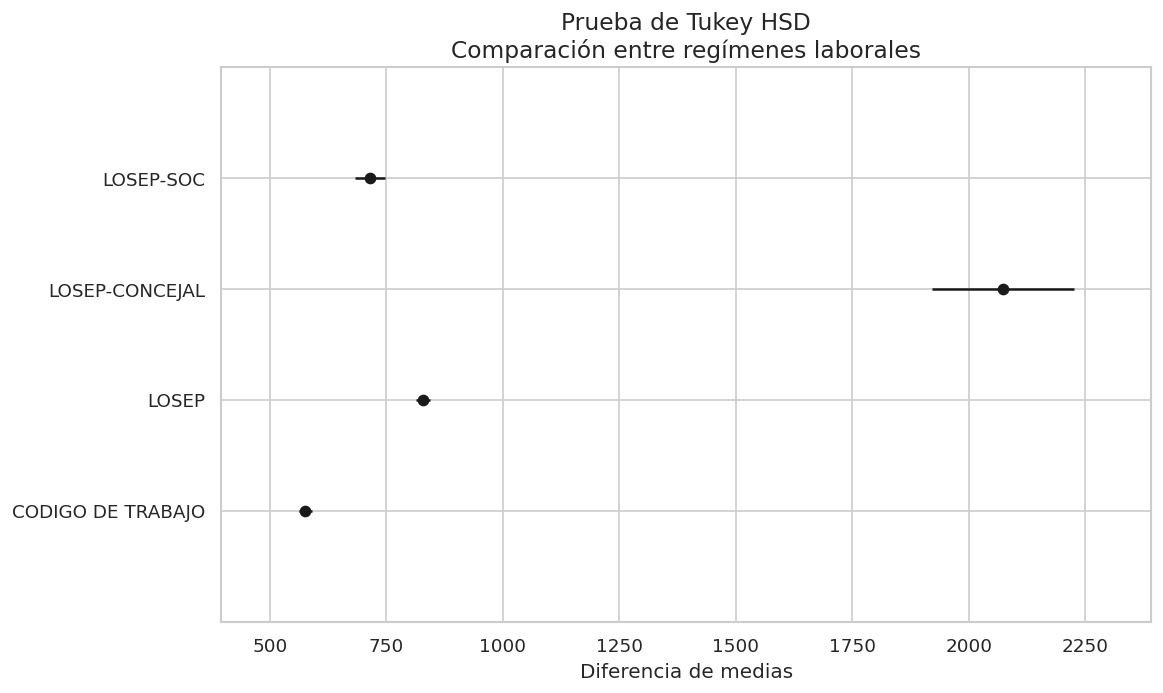


INTERPRETACIÓN

Se encontraron diferencias significativas entre los siguientes pares:

• CODIGO DE TRABAJO  vs  LOSEP | p-ajustado = 0.0000
• CODIGO DE TRABAJO  vs  LOSEP-CONCEJAL | p-ajustado = 0.0000
• CODIGO DE TRABAJO  vs  LOSEP-SOC | p-ajustado = 0.0000
• LOSEP  vs  LOSEP-CONCEJAL | p-ajustado = 0.0000
• LOSEP  vs  LOSEP-SOC | p-ajustado = 0.0000
• LOSEP-CONCEJAL  vs  LOSEP-SOC | p-ajustado = 0.0000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

variable_categorica = "Régimen laboral al que pertenece\xa0"
variable_numerica = "Remuneración mensual unificada"

datos = df[[variable_categorica, variable_numerica]].dropna()

# Prueba de Tukey HSD

tukey = pairwise_tukeyhsd(
    endog=datos[variable_numerica],
    groups=datos[variable_categorica],
    alpha=0.05
)

print("-"*70)
print("RESULTADOS DE LA PRUEBA POST HOC DE TUKEY")
print("-"*70)

print(tukey)

plt.figure(figsize=(10,6))
tukey.plot_simultaneous()
plt.title("Prueba de Tukey HSD\nComparación entre regímenes laborales")
plt.xlabel("Diferencia de medias")
plt.grid(True)
plt.show()

print("\n" + "-"*70)
print("INTERPRETACIÓN")
print("-"*70)

tabla = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

pares_significativos = tabla[tabla["reject"] == True]

if len(pares_significativos) == 0:
    print("\nNo se encontraron diferencias significativas entre los grupos.")
else:
    print("\nSe encontraron diferencias significativas entre los siguientes pares:\n")

    for _, fila in pares_significativos.iterrows():
        print(
            f"• {fila['group1']}  vs  {fila['group2']}"
            f" | p-ajustado = {fila['p-adj']:.4f}"
        )

# 📚 **Preguntas de Control**

### **Pregunta 1:**

## 🔬 Utilice `scipy.stats.levene` para verificar la igualdad de varianzas.

Se aplicó la prueba de **Levene** utilizando la función `scipy.stats.levene` con el propósito de verificar el supuesto de **homogeneidad de varianzas** requerido por el **ANOVA**.

- ✅ **Si el valor p obtenido es mayor que 0.05**, no se rechaza la hipótesis nula y se concluye que las varianzas son homogéneas, por lo que el supuesto del ANOVA se cumple.
- ❌ **Si el valor p es menor que 0.05**, se rechaza la hipótesis nula y se determina que existe heterogeneidad de varianzas, lo cual puede afectar la validez de los resultados del ANOVA.

---
### **Pregunta 2:**

## 💭 Discusión

### ❓ Si el supuesto de homocedasticidad se viola, ¿qué alternativa no paramétrica (ej. Kruskal-Wallis) sería adecuada?

Si la prueba de **Levene** indica que el supuesto de **homogeneidad de varianzas** se viola (**p < 0.05**), el **ANOVA** puede producir resultados poco confiables.

➡️ En este caso, una alternativa adecuada es la prueba no paramétrica de **Kruskal-Wallis** (`scipy.stats.kruskal`), ya que:

- 📌 No requiere que los datos tengan una distribución normal.
- 📌 No exige que las varianzas sean iguales entre los grupos.
- 📌 Compara los **rangos de las observaciones** entre los grupos para determinar si existen diferencias estadísticamente significativas.

✅ **Si Kruskal-Wallis también rechaza la hipótesis nula**, se recomienda realizar **comparaciones múltiples no paramétricas**, como la **prueba de Dunn** con corrección por comparaciones múltiples, para identificar específicamente qué grupos presentan diferencias.



---
📖 **Conclusión:** La prueba de **Levene** permite verificar si se cumple el supuesto de homogeneidad de varianzas del ANOVA. Cuando este supuesto no se satisface, **Kruskal-Wallis** constituye una alternativa robusta para comparar grupos sin depender de los supuestos de normalidad y homocedasticidad.

---
📖 **Conclusión:** La prueba de Levene se utiliza para verificar el supuesto de homogeneidad de varianzas exigido por el ANOVA. Si el valor p es mayor que 0.05, se considera que las varianzas son iguales y el ANOVA puede aplicarse con confianza. En cambio, si el valor p es menor que 0.05, dicho supuesto se incumple y los resultados del ANOVA pueden no ser fiables. En esta situación, una alternativa adecuada es la prueba no paramétrica de Kruskal-Wallis, ya que no depende del supuesto de igualdad de varianzas ni de la normalidad de los datos y permite evaluar si existen diferencias significativas entre los grupos mediante el análisis de rangos. Esta prueba constituye una opción robusta cuando no se cumplen los supuestos del ANOVA.

# 🤖 **Declaración de Uso de Inteligencia Artificial**

Durante el desarrollo de este trabajo se utilizó **ChatGPT** como herramienta de apoyo para:

- 💡 Comprender los conceptos teóricos relacionados con la actividad.
- 🐍 Interpretar y analizar los programas desarrollados en Python.
- 📝 Obtener orientación sobre la estructura y la implementación del código.
- 📚 Resolver dudas y reforzar la comprensión de aquellos temas que no se entendían completamente.

Es importante destacar que la inteligencia artificial fue utilizada **únicamente como una herramienta de apoyo al aprendizaje y al desarrollo del trabajo**, mientras que el análisis, la interpretación de los resultados y la elaboración de las conclusiones fueron realizados por los autores.

---
✅ **Link al chat generado con ChatGPT:** https://chatgpt.com/share/6a5e1f10-d508-83e9-9575-886fdc0b2903


# Bibliografía
[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy,
and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," SciPy.org, 2024. [Online].
Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html. [Accedido: 18-
Mar-2026].